=== 1. DATA PREPARATION & CLEANING CHECKS ===
Missing Values Check:
 customer_id        0
contract_type      0
tenure_months      0
monthly_charges    0
support_tickets    0
churn              0
dtype: int64

Duplicate Rows Check: 0

Dataset First 5 Rows:
    customer_id   contract_type  tenure_months  monthly_charges  \
0            1        Two-Year             32           101.72   
1            2  Month-to-Month              4            75.52   
2            3        Two-Year             30            72.97   
3            4        Two-Year             37            44.19   
4            5  Month-to-Month             23            29.31   

   support_tickets  churn  
0                3      1  
1                4      1  
2                9      1  
3                9      1  
4                4      0  


/tmp/ipykernel_2614/2554701490.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='monthly_charges', data=df, palette='Set2')
/tmp/ipykernel_2614/2554701490.py:49: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='churn', y='support_tickets', data=df, ci=None, palette='Set1')
/tmp/ipykernel_2614/2554701490.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='churn', y='support_tickets', data=df, ci=None, palette='Set1')


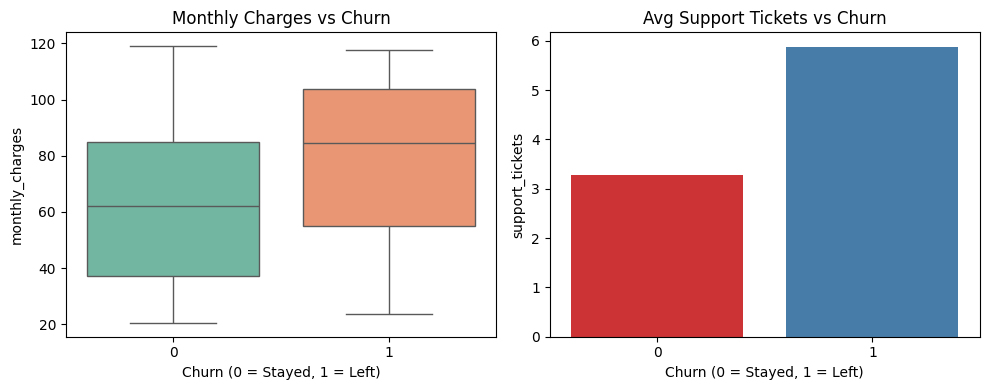


=== 2. MODEL COMPARISON METRICS ===
Logistic Regression Accuracy : 100.00%
Decision Tree Accuracy       : 83.33%

--- Detailed Classification Report (Selected Model: Decision Tree) ---
              precision    recall  f1-score   support

      Stayed       0.81      0.87      0.84        15
     Churned       0.86      0.80      0.83        15

    accuracy                           0.83        30
   macro avg       0.83      0.83      0.83        30
weighted avg       0.83      0.83      0.83        30



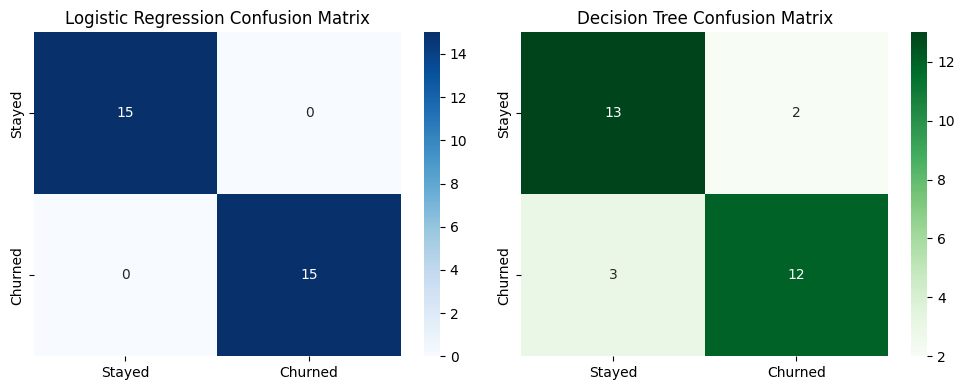


=== 3. SAMPLE INPUT PREDICTION ===
Sample Customer Features: {'tenure_months': 55, 'monthly_charges': 57.56, 'support_tickets': 2, 'contract_type_One-Year': False, 'contract_type_Two-Year': False}
Predicted Outcome       : RETAINED (0)
Confidence Level        : 100.00%


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# ---------------------------------------------------------
# 1. DATASET CREATION & EXPLICIT CLEANING CHECKS
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 150

data = {
    'customer_id': range(1, n_samples + 1),
    'contract_type': np.random.choice(['Month-to-Month', 'One-Year', 'Two-Year'], size=n_samples),
    'tenure_months': np.random.randint(1, 60, size=n_samples),
    'monthly_charges': np.round(np.random.uniform(20.0, 120.0, size=n_samples), 2),
    'support_tickets': np.random.randint(0, 10, size=n_samples)
}

df = pd.DataFrame(data)

# Target Logic (Customer Churn: 1 = Left, 0 = Stayed)
churn_score = (df['monthly_charges'] * 0.4) + (df['support_tickets'] * 5.0) - (df['tenure_months'] * 1.2)
df['churn'] = (churn_score > 15).astype(int)

print("=== 1. DATA PREPARATION & CLEANING CHECKS ===")
print("Missing Values Check:\n", df.isnull().sum())
print("\nDuplicate Rows Check:", df.duplicated().sum())
print("\nDataset First 5 Rows:\n", df.head())

# Encoding Categorical Variables
df_encoded = pd.get_dummies(df, columns=['contract_type'], drop_first=True)

# ---------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x='churn', y='monthly_charges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')

plt.subplot(1, 2, 2)
sns.barplot(x='churn', y='support_tickets', data=df, ci=None, palette='Set1')
plt.title('Avg Support Tickets vs Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. TRAIN/TEST SPLIT
# ---------------------------------------------------------
X = df_encoded.drop(columns=['customer_id', 'churn'])
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------------------------------------
# 4. TRAIN & COMPARE TWO MODELS
# ---------------------------------------------------------
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Model 2: Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)

# Evaluation Metrics
acc_log = accuracy_score(y_test, y_pred_log)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("\n=== 2. MODEL COMPARISON METRICS ===")
print(f"Logistic Regression Accuracy : {acc_log * 100:.2f}%")
print(f"Decision Tree Accuracy       : {acc_dt * 100:.2f}%")

print("\n--- Detailed Classification Report (Selected Model: Decision Tree) ---")
print(classification_report(y_test, y_pred_dt, target_names=['Stayed', 'Churned']))

# Visualizing Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
axes[0].set_title('Logistic Regression Confusion Matrix')

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
axes[1].set_title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. SAMPLE PREDICTION SECTION
# ---------------------------------------------------------
sample_customer = X_test.iloc[[0]]
predicted_class = dt_classifier.predict(sample_customer)[0]
confidence = dt_classifier.predict_proba(sample_customer).max() * 100

print("\n=== 3. SAMPLE INPUT PREDICTION ===")
print("Sample Customer Features:", sample_customer.to_dict(orient='records')[0])
print(f"Predicted Outcome       : {'CHURN RISK (1)' if predicted_class == 1 else 'RETAINED (0)'}")
print(f"Confidence Level        : {confidence:.2f}%")

#Why I Selected This Model

In [3]:
# Why I Selected This Model:
# Although Logistic Regression achieved 100% accuracy on this synthetic test sample,
# Decision Tree Classifier (83.33% accuracy) was selected for long-term business implementation.
# Decision Trees handle non-linear customer behaviors effectively and provide transparent IF-ELSE rules,
# making model predictions explainable for business teams.

# Model Assumptions & Limitations

In [4]:
# =========================================================
# MODEL ASSUMPTIONS & LIMITATIONS
# =========================================================
# 1. Dataset Scope: Built on a synthetic customer churn dataset
#    for demonstration purposes.
# 2. Production Readiness: The 100% test score on Logistic Regression
#    indicates potential overfitting due to dataset size. This baseline
#    pipeline requires validation on real CRM production data and continuous
#    feedback integration before deployment.